HOW TO SOLVE A MULTI-CLASS CLASSIFIATION PROBLEM ??IF THIS PROBLEM EXCITES YOU, THIS TUTORIAL IS FOR YOU. WE SHALL USE THE MNIST DATASET FOR THIS, AND OUR WORK WILL BE TO PREDICT THE NUMBER

In [1]:
import tensorflow 
from tensorflow import keras 
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense, Flatten

I0000 00:00:1783365603.877157   43392 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783365604.026995   43392 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783365607.176056   43392 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# import the mnist dataset from keras 
from tensorflow.keras.datasets import mnist 

(X_train, y_train),(X_test, y_test) = mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

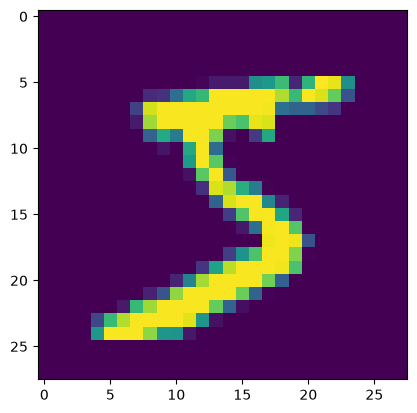

In [6]:
import matplotlib.pyplot as plt 
plt.imshow(X_train[0])
# so it is way to visualise the number/images 

In [7]:
# So you need to normalise the array, as it will be useful for convergence 
X_train = X_train/255
X_test = X_test/255

In [8]:
model = Sequential()

model.add(Flatten(input_shape = (28,28)))  # the model flattens the data 
# You can also call .reshape(rows, 784)...but its recommended not to do in a manual way 

# Add layers 
# another thing here you do not have to pass the number of imput nodes as the output of Flatten will be passed to the dense 
model.add(Dense(128, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(10, activation="softmax"))

/home/sanskar/jupyter-env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1783365610.968343   43392 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss="sparse_categorical_crossentropy", optimizer= "Adam",metrics= ["accuracy"])


#the difference between sparse_categorical_crossentropy as categorical_entropy is only that if you use 
#categorical_entropy you have to "hot encode, which is additonal work.....!!!!"


In [11]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10


W0000 00:00:1783365611.329307   43392 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9184 - loss: 0.2831 - val_accuracy: 0.9538 - val_loss: 0.1566
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9645 - loss: 0.1209 - val_accuracy: 0.9651 - val_loss: 0.1177
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9751 - loss: 0.0830 - val_accuracy: 0.9695 - val_loss: 0.1022
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9812 - loss: 0.0620 - val_accuracy: 0.9642 - val_loss: 0.1192
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9858 - loss: 0.0472 - val_accuracy: 0.9712 - val_loss: 0.1020
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9885 - loss: 0.0362 - val_accuracy: 0.9728 - val_loss: 0.1045
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9897 - loss: 0.0319 - val_accuracy: 0.9717 - val_loss: 0.1062
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9919 - loss: 0.0250 - val_accurac

In [12]:
y_prob = model.predict(X_test)

# so what this will do that it will return what is the probabilty of each of the images of 0 to 9
y_prob

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step


array([[3.0540681e-09, 1.0755095e-09, 4.4521351e-09, ..., 9.9999541e-01,
        5.3714604e-08, 2.6716825e-07],
       [2.8333565e-11, 8.8092206e-10, 9.9999994e-01, ..., 1.2207800e-14,
        3.8509690e-13, 5.7241633e-17],
       [6.5969225e-08, 9.9996096e-01, 7.8849956e-07, ..., 2.4225908e-05,
        6.1071162e-08, 1.2414863e-08],
       ...,
       [2.6336386e-19, 1.2864296e-12, 6.7393602e-18, ..., 6.6820549e-11,
        6.0394794e-13, 8.3162934e-09],
       [2.4374940e-14, 2.3952926e-13, 1.5002428e-17, ..., 2.2359728e-14,
        1.4745368e-07, 7.6150300e-16],
       [3.9678458e-15, 1.1105750e-14, 6.5416688e-16, ..., 6.4466338e-18,
        4.2453265e-17, 9.9400547e-17]], shape=(10000, 10), dtype=float32)

In [13]:
# but we have to take the max probability 
y_pred = y_prob.argmax(axis=1)

In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9784

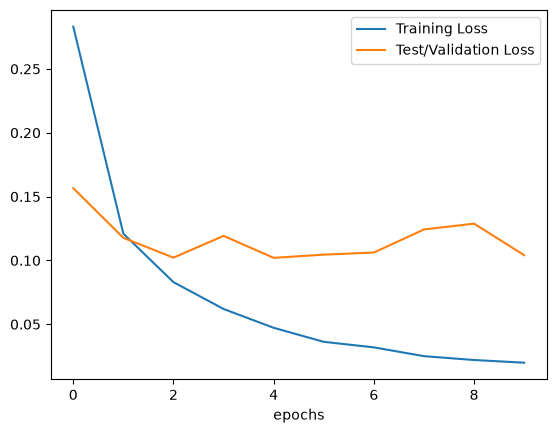

In [20]:
plt.plot(history.history["loss"], label= "Training Loss")
plt.plot(history.history["val_loss"], label= "Test/Validation Loss")
plt.xlabel("epochs")
plt.legend()

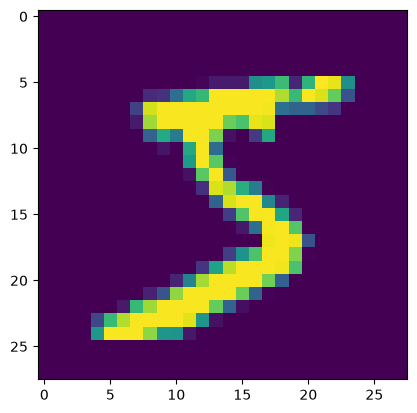

In [27]:
# Test for a particular image 
plt.imshow(X_train[0])


In [28]:
model.predict(X_train[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([5])